# 3 — Measuring things after training

`TrainedWavefunction` is a frozen `psi` with `(model, params, coord_mode, box)` baked
in. It owns its sampler and caches its samples, and every estimator reads from that
cache.

It takes a `Sampler`, the same abstraction training uses — so a constrained run is
post-analysed under the constraint it was trained with, which used to be impossible.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import optax

## An exactly known state

To check the estimators against something, use the analytic harmonic-oscillator ground
state: `log|psi_0| = -x^2 / 2` per particle. Then `|psi_0|^2` samples are `N(0, 1/2)`
and the single-particle density is `n(x) = N * exp(-x^2) / sqrt(pi)`.

This is also a nice demonstration that "the ansatz" is just any `nn.Module` returning
a log-amplitude — it needs no parameters at all.

In [2]:
import flax.linen as nn
import jax
import jax.numpy as jnp

class ExactHO(nn.Module):
    """The analytic 1-D HO ground state: log|psi| = -sum_i x_i^2 / 2."""

    @nn.compact
    def __call__(self, x):
        return -0.5 * jnp.sum(x**2, axis=-1, keepdims=True)

n_particles = 3
model = ExactHO()
params = model.init(jax.random.PRNGKey(0), jnp.ones((1, n_particles)))

In [3]:
from qvarnet import Metropolis
from qvarnet.analysis.estimators import TrainedWavefunction

wf = TrainedWavefunction(
    model, params, n_particles=n_particles, n_dim=1,
    sampler=Metropolis(),     # pass OrderedMetropolis() for a constrained run
    seed=0,
)
samples = wf.sample(n_chains=512, n_steps=600, burn_in=100, thinning=4, step_size=0.8)
print("samples:", samples.shape, " acceptance: %.3f" % wf.acceptance_rate)

IAT: 6.27  mean ESS: 118.8
samples: (64000, 3)  acceptance: 0.400


The printed IAT is the integrated autocorrelation time: how many chain steps until
samples are effectively independent. It is a diagnostic here, not a thinning rule —
`thinning` is yours to set. See `docs/explainers/autocorrelation.md`.

> `burn_in` means *discard the first N steps*. That was a genuine bug until recently:
> the code treated it as "keep the last N", so the defaults silently threw away three
> quarters of the usable samples.

## Density, against the analytic answer

max deviation from exact: 0.0208   (integral 3.000, exact 3)


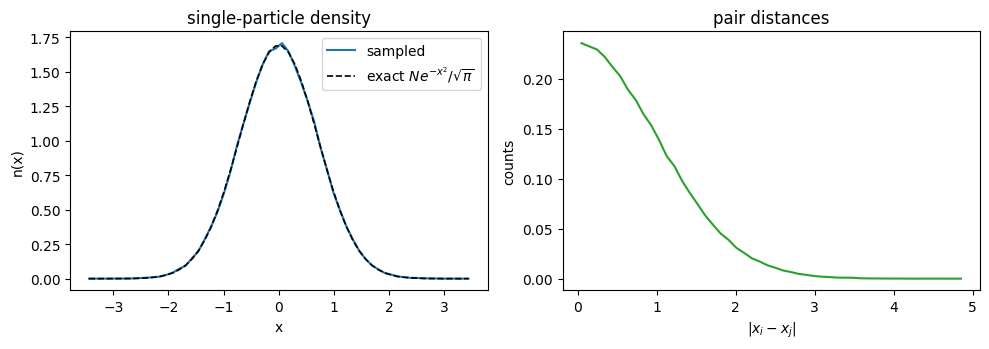

In [4]:
centers, density = wf.density(bins=60, value_range=(-3.5, 3.5))
exact = n_particles * np.exp(-centers**2) / np.sqrt(np.pi)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(centers, density, lw=1.5, label="sampled")
ax[0].plot(centers, exact, "k--", lw=1.2, label=r"exact $N e^{-x^2}/\sqrt{\pi}$")
ax[0].set(xlabel="x", ylabel="n(x)", title="single-particle density")
ax[0].legend()

r, g = wf.pair_correlation(bins=50)
ax[1].plot(r, g, lw=1.5, color="tab:green")
ax[1].set(xlabel=r"$|x_i - x_j|$", ylabel="counts", title="pair distances")
fig.tight_layout()

err = np.max(np.abs(density - exact))
print(f"max deviation from exact: {err:.4f}   (integral {np.trapezoid(density, centers):.3f}, exact {n_particles})")

## Error bars

`blocking_error` gives the Flyvbjerg–Petersen estimate: it averages over blocks long
enough to be independent, so it accounts for autocorrelation. The naive `sigma/sqrt(M)`
does not, and is therefore too small.

<x_0>        = -0.00326
blocked err  = 0.00609
naive err    = 0.00280
ratio        = 2.18x  (the correlation you would miss)


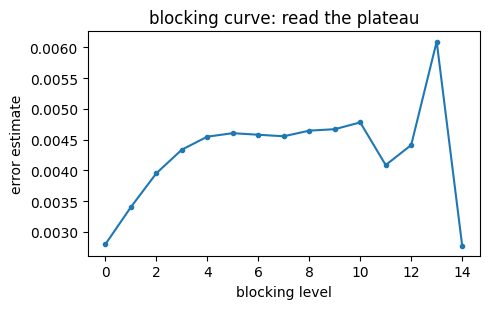

In [5]:
from qvarnet.analysis.estimators import blocking_error, mean_and_error

x0 = np.asarray(wf.samples)[:, 0]          # one coordinate's series
mean, err_blocked = mean_and_error(x0)
err_naive = x0.std(ddof=1) / np.sqrt(x0.size)

print(f"<x_0>        = {mean:+.5f}")
print(f"blocked err  = {err_blocked:.5f}")
print(f"naive err    = {err_naive:.5f}")
print(f"ratio        = {err_blocked / err_naive:.2f}x  (the correlation you would miss)")

_, curve = blocking_error(x0)
plt.figure(figsize=(5, 3.2))
plt.plot(curve, "o-", ms=3)
plt.xlabel("blocking level"); plt.ylabel("error estimate")
plt.title("blocking curve: read the plateau")
plt.tight_layout()

The blocking curve rises and then flattens. The plateau is the honest error; reading
it at level 0 is the naive estimate.

**Note the gap this leaves.** These estimator methods return bare values, not
`(value, error)` pairs, and the energy error bar in `result.history` is still the naive
one. That is tracked in `docs/adr/0001-correlated-error-estimates.md` — including the
fact that it reaches published sweep numbers.

## Growing the sample pool

`sample_more` continues the same chains and appends, so statistics improve without
re-thermalising.

In [6]:
before = wf.samples.shape[0]
wf.sample_more(n_steps=300, burn_in=0, thinning=4)
print(f"pool: {before} -> {wf.samples.shape[0]} samples")

IAT: 6.12  mean ESS: 12.6
pool: 64000 -> 102400 samples


## Structure factor

S(k) needs a length scale to pick commensurate k, so pass `k_values` explicitly for a
trapped (non-periodic) system.

S(k) -> 1 at large k: 0.999


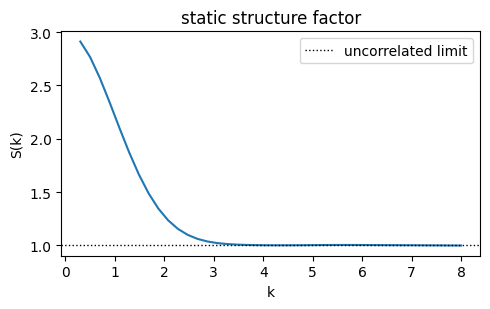

In [7]:
k = np.linspace(0.3, 8.0, 40)
k_out, S = wf.structure_factor(k_values=k)

plt.figure(figsize=(5, 3.2))
plt.plot(k_out, S, lw=1.5)
plt.axhline(1.0, color="k", ls=":", lw=1, label="uncorrelated limit")
plt.xlabel("k"); plt.ylabel("S(k)"); plt.title("static structure factor")
plt.legend(); plt.tight_layout()
print("S(k) -> 1 at large k:", f"{S[-1]:.3f}")

`S(k) -> 1` at large k is the model-independent sanity check: at short wavelengths you
resolve individual particles and see no correlation.

`wf.obdm(grid)`, `wf.natural_orbitals()` and `wf.condensate_fraction()` cover the
one-body density matrix; for a single particle the condensate fraction is exactly 1,
which is the cheapest test that the OBDM machinery is wired up correctly.